# R5 — Resultados de Clasificación de Sentimiento (5 empresas BVL)

Explora la salida del pipeline de sentimiento (R5): clasificación zero-shot
(positivo / negativo / neutral) de noticias de MediaCloud vía LLM local
(Ollama `gemma3:4b`, prompt `v1`), agregada a un score diario por activo.

Objetivos:
- Validar la calidad de la clasificación (distribución de etiquetas, confianza
  del modelo, revisión cualitativa de titulares).
- Medir la cobertura temporal del dato de sentimiento frente al calendario de
  mercado.
- Responder la pregunta central para la tesis: **¿el sentimiento diario tiene
  relación con el comportamiento de precios (mismo día o día siguiente)?**

| Ticker | Empresa | Sector |
|--------|---------|--------|
| CREDITC1 | Banco de Crédito del Perú | Banca |
| BUENAVC1 | Cía. de Minas Buenaventura | Minería |
| ALICORC1 | Alicorp | Alimentos |
| SAGAC1 | Saga Falabella | Retail |
| CORAREC1 | Corporación Aceros Arequipa | Manufactura |


In [1]:
%matplotlib inline
import sys, json, pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(pathlib.Path.cwd().parent))

DATA_RAW     = pathlib.Path('../data/raw')
DATA_INTERIM = pathlib.Path('../data/interim')
CACHE_DIR    = DATA_INTERIM / 'sentiment_cache'

TICKERS = ['CREDITC1', 'BUENAVC1', 'ALICORC1', 'SAGAC1', 'CORAREC1']
NOMBRES = {
    'CREDITC1': 'BCP',
    'BUENAVC1': 'Buenaventura',
    'ALICORC1': 'Alicorp',
    'SAGAC1':   'Saga Falabella',
    'CORAREC1': 'Aceros Arequipa',
}
COLORES = dict(zip(TICKERS, ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']))
LABEL_SCORE = {'positivo': 1.0, 'neutral': 0.0, 'negativo': -1.0}
LABEL_ORDER = ['negativo', 'neutral', 'positivo']
LABEL_COLOR = {'negativo': '#F44336', 'neutral': '#9E9E9E', 'positivo': '#4CAF50'}

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})


## 1. Carga de datos

Tres capas: **(a)** score diario agregado (`sentiment_{TICKER}.parquet`), **(b)** detalle por noticia (cruce de `news_{TICKER}.parquet` con el caché del clasificador) y **(c)** mercado (`market_{TICKER}.parquet`, R3) para el cruce de la sección 9.

In [2]:
daily = {}
for ticker in TICKERS:
    p = DATA_INTERIM / f'sentiment_{ticker}.parquet'
    if p.exists():
        df = pd.read_parquet(p)
        df['date'] = pd.to_datetime(df['date'])
        daily[ticker] = df.sort_values('date').reset_index(drop=True)

print(f'Activos con sentimiento diario: {list(daily.keys())}')
for t, df in daily.items():
    print(f'  {t:10} {len(df):>5} días  [{df["date"].min().date()} -> {df["date"].max().date()}]')


Activos con sentimiento diario: ['CREDITC1', 'BUENAVC1', 'ALICORC1', 'SAGAC1', 'CORAREC1']
  CREDITC1    2734 días  [2013-03-27 -> 2025-12-31]
  BUENAVC1     697 días  [2013-03-18 -> 2025-12-24]
  ALICORC1    1085 días  [2013-02-08 -> 2025-12-31]
  SAGAC1       331 días  [2013-04-01 -> 2025-12-29]
  CORAREC1     495 días  [2013-08-09 -> 2025-12-29]


In [3]:
def cargar_articulos(ticker: str) -> pd.DataFrame:
    news = pd.read_parquet(DATA_RAW / f'news_{ticker}.parquet')
    cache = json.loads((CACHE_DIR / f'cache_{ticker}.json').read_text(encoding='utf-8'))

    key = news['id'].astype(str)
    if 'url' in news.columns:
        key = key.where(news['id'].notna() & (key != ''), news['url'].astype(str))

    clasif = key.map(cache)
    news = news.assign(
        sentiment  = clasif.map(lambda d: d.get('sentiment') if isinstance(d, dict) else None),
        confidence = clasif.map(lambda d: d.get('confidence') if isinstance(d, dict) else None),
    )
    news['score'] = news['sentiment'].map(LABEL_SCORE)
    news['publish_date'] = pd.to_datetime(news['publish_date'])
    return news

articles = {t: cargar_articulos(t) for t in TICKERS if (DATA_RAW / f'news_{t}.parquet').exists()}
total = sum(len(df) for df in articles.values())
sin_clasificar = sum(int(df['sentiment'].isna().sum()) for df in articles.values())
print(f'Noticias totales: {total}  |  sin clasificar (no encontradas en caché): {sin_clasificar}')


Noticias totales: 11566  |  sin clasificar (no encontradas en caché): 0


In [4]:
market = {}
for ticker in TICKERS:
    p = DATA_INTERIM / f'market_{ticker}.parquet'
    if p.exists():
        df = pd.read_parquet(p)
        df['date'] = pd.to_datetime(df['date'])
        market[ticker] = df.sort_values('date').reset_index(drop=True)[['date', 'close', 'ret_1d', 'volatility_20']]

print(f'Activos con mercado: {list(market.keys())}')


Activos con mercado: ['CREDITC1', 'BUENAVC1', 'ALICORC1', 'SAGAC1', 'CORAREC1']


## 2. Resumen general por activo

In [5]:
resumen = []
for t in TICKERS:
    art = articles.get(t, pd.DataFrame())
    d = daily.get(t, pd.DataFrame())
    n = len(art)
    vc = art['sentiment'].value_counts(normalize=True) if n else pd.Series(dtype=float)
    resumen.append({
        'Ticker': t,
        'Empresa': NOMBRES[t],
        'Noticias clasificadas': n,
        'Días con sentimiento': len(d),
        'Score diario medio': d['sentiment_score'].mean() if len(d) else np.nan,
        'Score diario std': d['sentiment_score'].std() if len(d) else np.nan,
        '% positivo': round(100 * vc.get('positivo', 0.0), 1),
        '% neutral':  round(100 * vc.get('neutral', 0.0), 1),
        '% negativo': round(100 * vc.get('negativo', 0.0), 1),
        'Confianza media': round(art['confidence'].mean(), 3) if n else np.nan,
    })

df_resumen = pd.DataFrame(resumen).set_index('Ticker')
df_resumen


,Empresa,Noticias clasificadas,Días con sentimiento,Score diario medio,Score diario std,% positivo,% neutral,% negativo,Confianza media
Ticker,,,,,,,,,
CREDITC1,BCP,7933,2734,-0.073280,0.591372,24.9,41.5,33.6,0.731
BUENAVC1,Buenaventura,978,697,0.069273,0.905985,47.1,11.0,41.8,0.787
ALICORC1,Alicorp,1585,1085,0.041314,0.799413,39.3,25.2,35.5,0.761
SAGAC1,Saga Falabella,380,331,0.032226,0.787616,32.1,34.2,33.7,0.724
CORAREC1,Aceros Arequipa,690,495,-0.031481,0.854689,38.4,20.7,40.9,0.767


## 3. Distribución de etiquetas de sentimiento (a nivel de noticia)

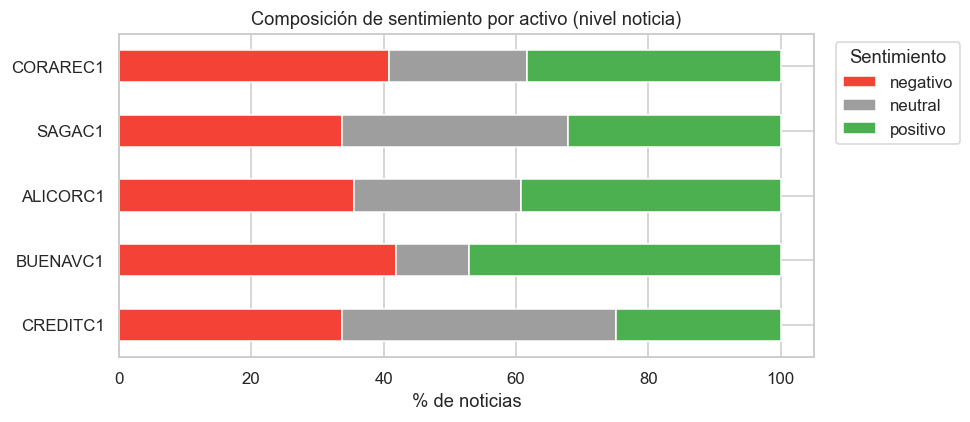

sentiment,negativo,neutral,positivo
CREDITC1,33.6,41.5,24.9
BUENAVC1,41.8,11.0,47.1
ALICORC1,35.5,25.2,39.3
SAGAC1,33.7,34.2,32.1
CORAREC1,40.9,20.7,38.4


In [6]:
dist = pd.DataFrame({
    t: articles[t]['sentiment'].value_counts(normalize=True).reindex(LABEL_ORDER).fillna(0) * 100
    for t in TICKERS if t in articles
}).T

fig, ax = plt.subplots(figsize=(9, 4))
dist[LABEL_ORDER].plot(kind='barh', stacked=True, ax=ax,
                        color=[LABEL_COLOR[l] for l in LABEL_ORDER])
ax.set_xlabel('% de noticias')
ax.set_ylabel('')
ax.set_title('Composición de sentimiento por activo (nivel noticia)')
ax.legend(title='Sentimiento', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

dist.round(1)


## 4. Confianza del modelo (LLM)

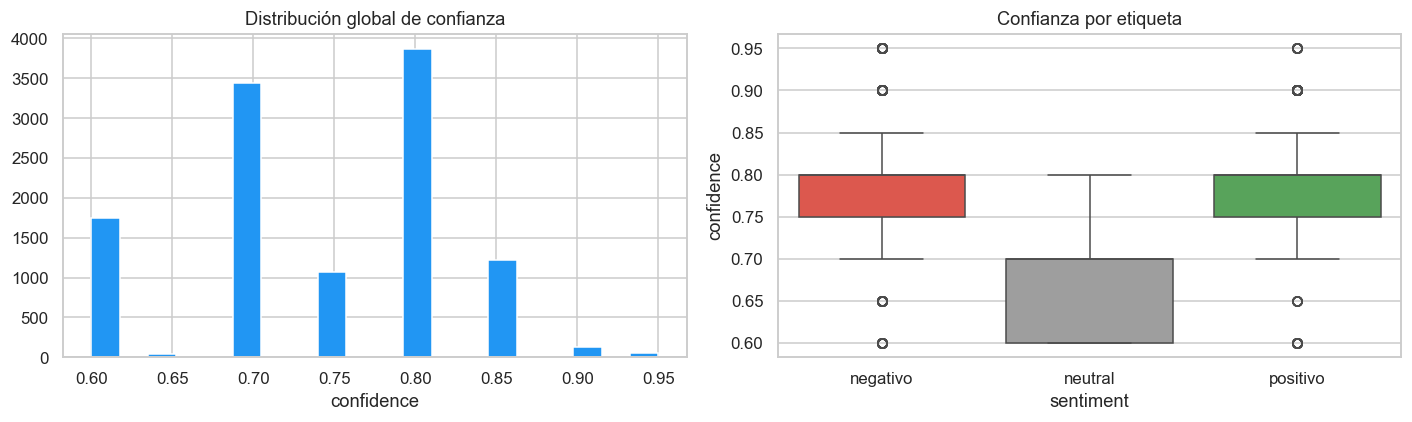

,count,mean,std,min,max
sentiment,,,,,
negativo,4050.0,0.785123,0.057391,0.6,0.95
neutral,4072.0,0.668492,0.064977,0.6,0.80
positivo,3444.0,0.778354,0.053795,0.6,0.95


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

todas = pd.concat([articles[t][['confidence']].assign(ticker=t) for t in articles])
axes[0].hist(todas['confidence'].dropna(), bins=20, color='#2196F3', edgecolor='white')
axes[0].set_title('Distribución global de confianza')
axes[0].set_xlabel('confidence')

por_label = pd.concat([articles[t][['sentiment', 'confidence']] for t in articles])
sns.boxplot(data=por_label, x='sentiment', y='confidence', order=LABEL_ORDER,
            palette=LABEL_COLOR, ax=axes[1])
axes[1].set_title('Confianza por etiqueta')
plt.tight_layout()
plt.show()

por_label.groupby('sentiment')['confidence'].describe()[['count', 'mean', 'std', 'min', 'max']].reindex(LABEL_ORDER)


## 5. Serie temporal del score diario de sentimiento

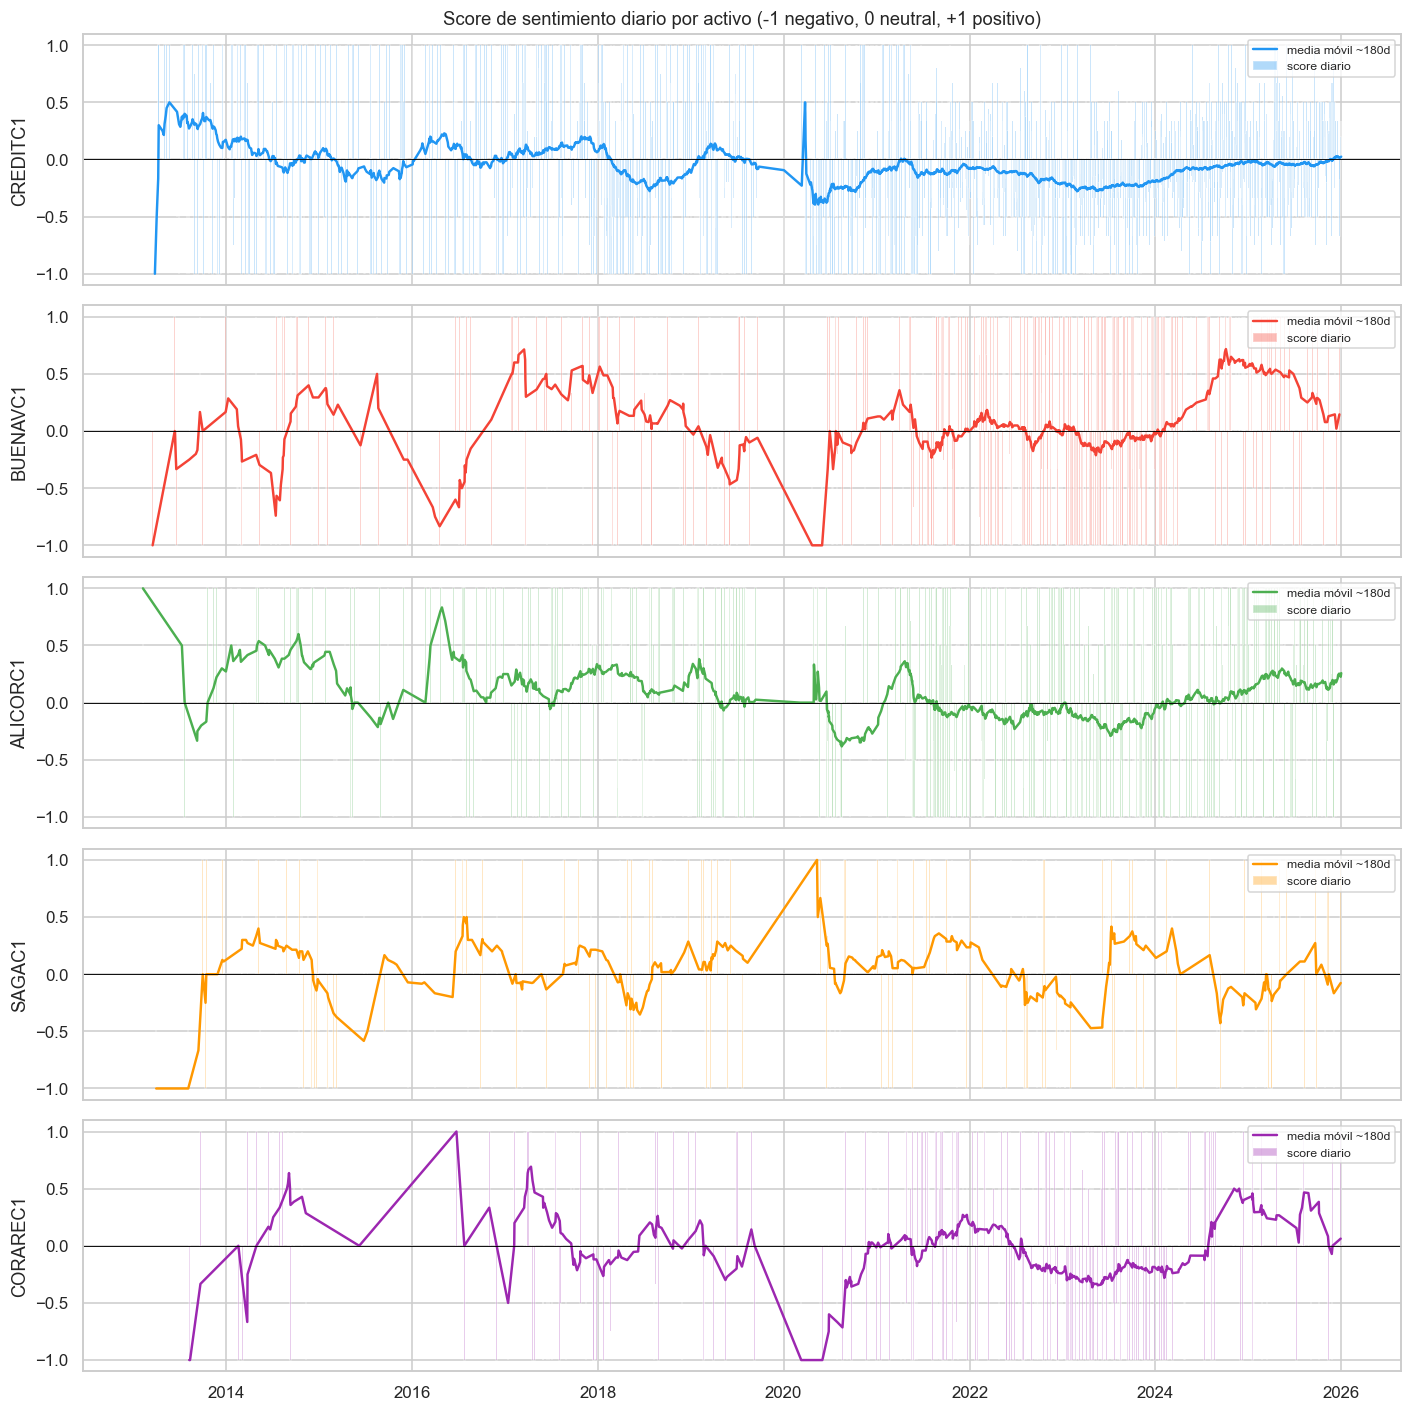

In [8]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(13, 2.6 * len(TICKERS)), sharex=True)
for ax, t in zip(axes, TICKERS):
    if t not in daily:
        continue
    d = daily[t]
    ax.bar(d['date'], d['sentiment_score'], width=2, color=COLORES[t], alpha=0.35, label='score diario')
    suavizado = d.set_index('date')['sentiment_score'].rolling('180D').mean()
    ax.plot(suavizado.index, suavizado.values, color=COLORES[t], linewidth=1.6, label='media móvil ~180d')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_ylabel(t)
    ax.set_ylim(-1.1, 1.1)
    ax.legend(loc='upper right', fontsize=8)

axes[0].set_title('Score de sentimiento diario por activo (-1 negativo, 0 neutral, +1 positivo)')
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


## 6. Cobertura temporal del dato de sentimiento

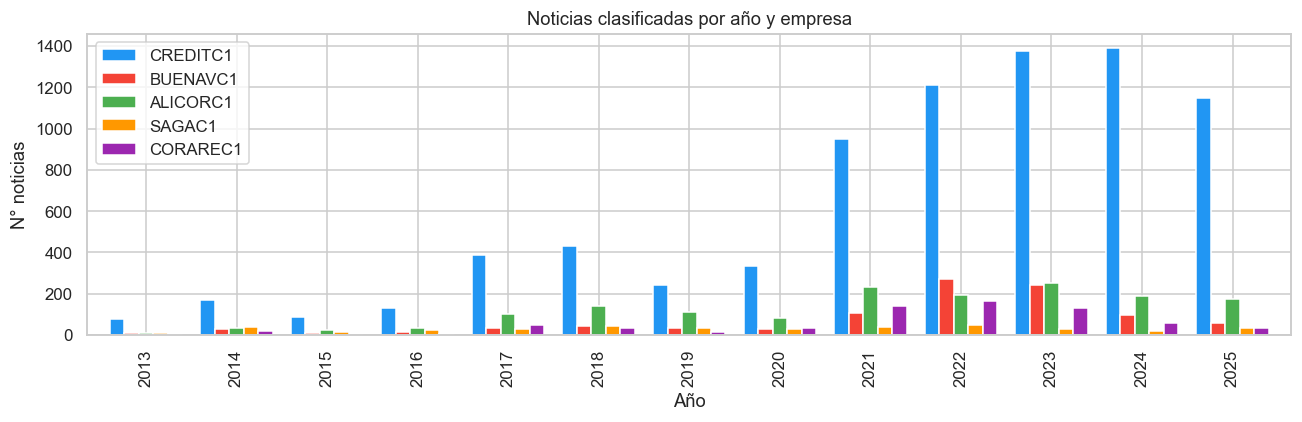

,Días de mercado,Días con sentimiento,% cobertura
Ticker,,,
CREDITC1,3511,2734,58.3
BUENAVC1,3499,697,18.3
ALICORC1,3513,1085,25.9
SAGAC1,3321,331,7.7
CORAREC1,3513,495,12.2


In [9]:
yearly = pd.DataFrame({
    t: articles[t].assign(year=articles[t]['publish_date'].dt.year).groupby('year').size()
    for t in articles
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 4))
yearly.plot(kind='bar', ax=ax, width=0.8, color=[COLORES[t] for t in yearly.columns])
ax.set_title('Noticias clasificadas por año y empresa')
ax.set_xlabel('Año'); ax.set_ylabel('N° noticias')
plt.tight_layout()
plt.show()

cobertura = []
for t in TICKERS:
    if t not in market or t not in daily:
        continue
    dias_mercado = set(market[t]['date'].dt.normalize())
    dias_sentimiento = set(pd.to_datetime(daily[t]['date']).dt.normalize())
    pct = 100 * len(dias_sentimiento.intersection(dias_mercado)) / len(dias_mercado)
    cobertura.append({'Ticker': t, 'Días de mercado': len(dias_mercado),
                       'Días con sentimiento': len(dias_sentimiento),
                       '% cobertura': round(pct, 1)})
df_cobertura = pd.DataFrame(cobertura).set_index('Ticker')
df_cobertura


## 7. Sesgo por medio de comunicación

In [10]:
top_medios = []
for t in TICKERS:
    if t not in articles:
        continue
    g = (articles[t].dropna(subset=['score'])
                     .groupby('media_name')
                     .agg(n=('score', 'size'), score_medio=('score', 'mean'))
                     .sort_values('n', ascending=False)
                     .head(5))
    g['ticker'] = t
    top_medios.append(g.reset_index())

pd.concat(top_medios).set_index(['ticker', 'media_name']).round(2)


n  score_medio
ticker   media_name                       
CREDITC1 larepublica.pe  2880        -0.20
         gestion.pe      2752        -0.03
         elcomercio.pe   2301        -0.03
BUENAVC1 gestion.pe       636         0.06
         elcomercio.pe    232         0.02
         larepublica.pe   110         0.12
ALICORC1 gestion.pe       910         0.05
         elcomercio.pe    486         0.01
         larepublica.pe   189         0.08
SAGAC1   gestion.pe       152         0.06
         larepublica.pe   122        -0.22
         elcomercio.pe    106         0.11
CORAREC1 gestion.pe       397        -0.04
         elcomercio.pe    206        -0.06
         larepublica.pe    87         0.14

## 8. Validación cualitativa: titulares extremos

Chequeo de cordura (*face validity*): las 3 noticias positivas y las 3 negativas con mayor confianza del modelo, por activo.

In [11]:
for t in TICKERS:
    if t not in articles:
        continue
    art = articles[t].dropna(subset=['score', 'confidence'])
    pos = art[art['sentiment'] == 'positivo'].nlargest(3, 'confidence')
    neg = art[art['sentiment'] == 'negativo'].nlargest(3, 'confidence')
    print(f'\n=== {t} ({NOMBRES[t]}) ===')
    print('-- Más positivas --')
    for _, r in pos.iterrows():
        print(f'  [{r["confidence"]:.2f}] {r["publish_date"].date()}  {r["title"]}')
    print('-- Más negativas --')
    for _, r in neg.iterrows():
        print(f'  [{r["confidence"]:.2f}] {r["publish_date"].date()}  {r["title"]}')



=== CREDITC1 (BCP) ===
-- Más positivas --
  [0.95] 2022-05-13  Bolsa de Valores de Lima cerró la jornada en terreno positivo con 3,28%, hoy viernes 13 de mayo
  [0.95] 2022-07-21  Bolsa de Valores de Lima cerró la jornada en terreno positivo con 2,12% y 15 indicadores al alza
  [0.95] 2022-08-04  Bolsa de Valores de Lima cerró la jornada en terreno positivo con 0,28% y 11 indicadores al alza
-- Más negativas --
  [0.95] 2016-12-07  San Borja: roban 81 mil dólares a cambista dentro de un carro
  [0.95] 2017-03-31  Credicorp: Pérdidas superarían los US$4 millones
  [0.95] 2025-08-09  ¡ALERTA YAPEROS! Así funciona la nueva estafa que usa correos falsos para robarte tu dinero

=== BUENAVC1 (Buenaventura) ===
-- Más positivas --
  [0.95] 2022-06-24  Bolsa de Valores de Lima cerró la jornada en terreno positivo con 1,92% y 16 indicadores al alza
  [0.95] 2022-08-08  Bolsa de Valores de Lima cerró la jornada en terreno positivo con 2,47% y 13 indicadores al alza
  [0.90] 2025-04-17  Producc

## 9. Sentimiento vs. mercado: ¿hay señal?

Se cruza el score diario con el retorno (`ret_1d`) del **mismo día** y con el retorno del **día hábil siguiente** (`ret_1d` desplazado -1 dentro de cada activo). La correlación con `t+1` es la que importa para un insumo de DRL: mide si el sentimiento de hoy anticipa el movimiento de precio de la siguiente sesión, no si simplemente coincide con la noticia del día (que puede ser una reacción al precio, no una causa).

In [12]:
def cruzar_mercado(t):
    d = daily[t][['date', 'sentiment_score', 'n_articles']]
    m = market[t].copy()
    m['ret_next'] = m['ret_1d'].shift(-1)
    out = m.merge(d, on='date', how='inner')
    out['ticker'] = t
    return out

cruces = {t: cruzar_mercado(t) for t in TICKERS if t in daily and t in market}

corr_rows = []
for t, df in cruces.items():
    v = df.dropna(subset=['sentiment_score', 'ret_1d', 'ret_next'])
    corr_rows.append({
        'Ticker': t,
        'N (días)': len(v),
        'Pearson score~ret(t)':    v['sentiment_score'].corr(v['ret_1d']),
        'Pearson score~ret(t+1)':  v['sentiment_score'].corr(v['ret_next']),
        'Spearman score~ret(t+1)': v['sentiment_score'].rank().corr(v['ret_next'].rank()),
    })

df_corr = pd.DataFrame(corr_rows).set_index('Ticker').round(3)
df_corr


,N (días),Pearson score~ret(t),Pearson score~ret(t+1),Spearman score~ret(t+1)
Ticker,,,,
CREDITC1,2046,0.018,0.032,0.009
BUENAVC1,640,0.001,0.040,0.010
ALICORC1,910,-0.007,0.081,0.084
SAGAC1,255,0.009,0.010,0.008
CORAREC1,427,0.003,0.020,0.014


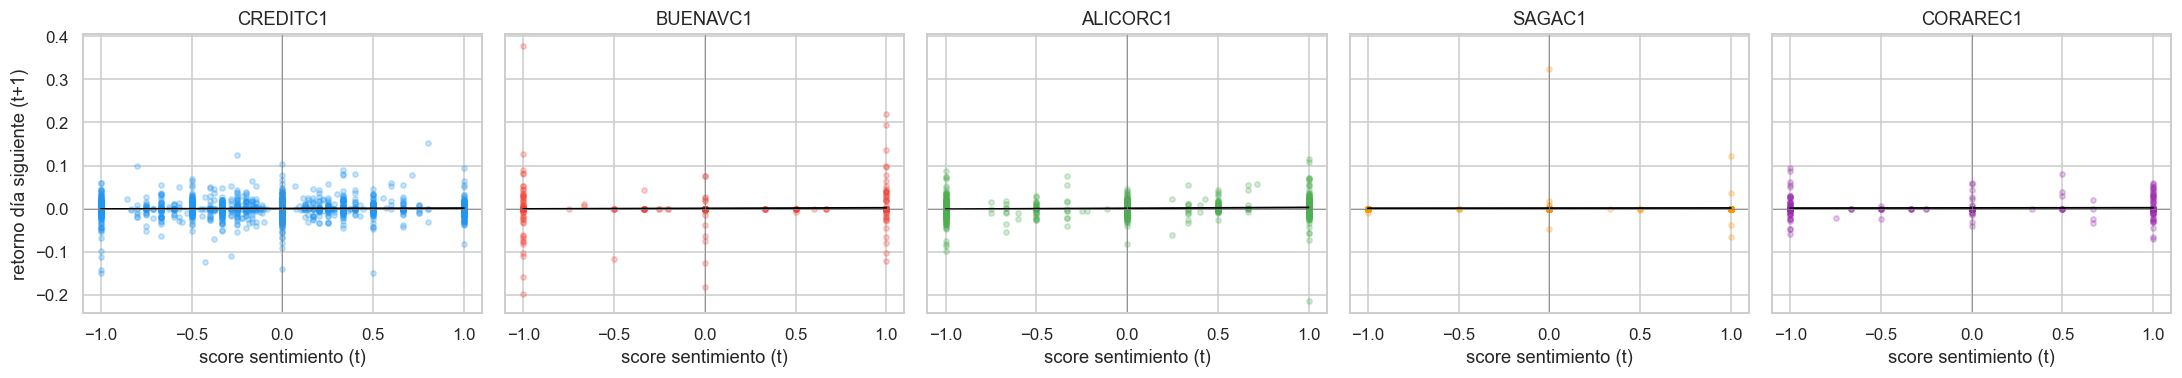

In [13]:
fig, axes = plt.subplots(1, len(cruces), figsize=(4 * len(cruces), 3.6), sharey=True)
for ax, (t, df) in zip(axes, cruces.items()):
    dfx = df.dropna(subset=['sentiment_score', 'ret_next'])
    ax.scatter(dfx['sentiment_score'], dfx['ret_next'], alpha=0.25, s=12, color=COLORES[t])
    if len(dfx) > 2:
        b, a = np.polyfit(dfx['sentiment_score'], dfx['ret_next'], 1)
        xs = np.linspace(-1, 1, 50)
        ax.plot(xs, a + b * xs, color='black', linewidth=1.2)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_title(t)
    ax.set_xlabel('score sentimiento (t)')
axes[0].set_ylabel('retorno día siguiente (t+1)')
plt.tight_layout()
plt.show()


## 10. Retorno condicionado al signo del sentimiento (análisis de evento)

Se agrupan los días en negativo / neutral / positivo (umbral ±0.2 sobre el score diario) y se compara el retorno medio del día siguiente entre grupos — la pregunta de negocio en su forma más simple: *¿el día después de noticias positivas el precio sube más que el día después de noticias negativas?*

In [14]:
def clasificar_signo(s, umbral=0.2):
    if s > umbral:
        return 'positivo'
    if s < -umbral:
        return 'negativo'
    return 'neutral'

evento_rows = []
for t, df in cruces.items():
    dfx = df.dropna(subset=['sentiment_score', 'ret_next']).copy()
    dfx['signo'] = dfx['sentiment_score'].apply(clasificar_signo)
    g = dfx.groupby('signo')['ret_next'].agg(['mean', 'std', 'count']).reindex(LABEL_ORDER)
    g.columns = pd.MultiIndex.from_product([[t], g.columns])
    evento_rows.append(g)

tabla_evento = pd.concat(evento_rows, axis=1).round(4)
tabla_evento


CREDITC1               BUENAVC1               ALICORC1                \
             mean     std count     mean     std count     mean     std count   
signo                                                                           
negativo  -0.0002  0.0200   801   0.0001  0.0363   255  -0.0010  0.0205   322   
neutral   -0.0002  0.0177   665  -0.0031  0.0297    84   0.0006  0.0140   239   
positivo   0.0016  0.0185   580   0.0026  0.0252   301   0.0029  0.0222   349   

          SAGAC1               CORAREC1                
            mean     std count     mean     std count  
signo                                                  
negativo -0.0001  0.0010    74   0.0013  0.0155   184  
neutral   0.0033  0.0341    93   0.0013  0.0123    86  
positivo  0.0006  0.0158    88   0.0025  0.0186   157

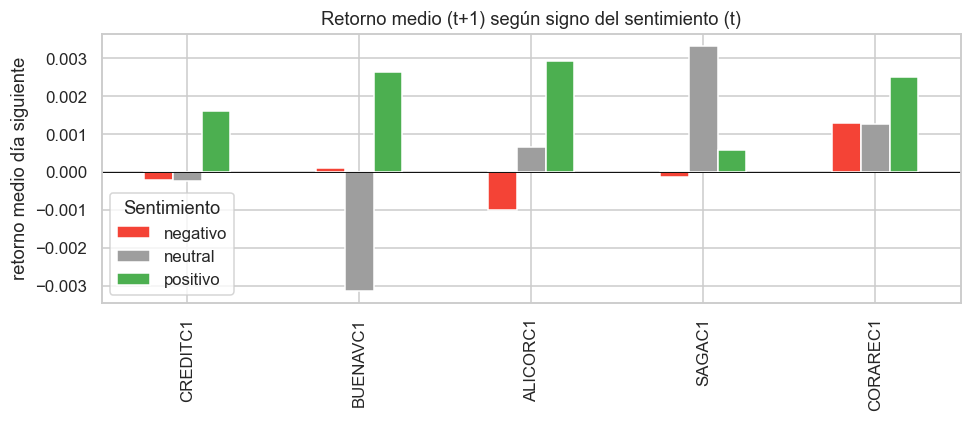

In [15]:
medias = pd.DataFrame({
    t: cruces[t].dropna(subset=['sentiment_score', 'ret_next'])
               .assign(signo=lambda d: d['sentiment_score'].apply(clasificar_signo))
               .groupby('signo')['ret_next'].mean().reindex(LABEL_ORDER)
    for t in cruces
})

fig, ax = plt.subplots(figsize=(9, 4))
medias.T.plot(kind='bar', ax=ax, color=[LABEL_COLOR[l] for l in LABEL_ORDER])
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('retorno medio día siguiente')
ax.set_title('Retorno medio (t+1) según signo del sentimiento (t)')
ax.legend(title='Sentimiento')
plt.tight_layout()
plt.show()


## 11. Volumen de noticias vs. volatilidad

In [16]:
vol_rows = []
for t, df in cruces.items():
    dfx = df.dropna(subset=['n_articles', 'volatility_20'])
    vol_rows.append({
        'Ticker': t,
        'N (días)': len(dfx),
        'Corr. n_articles~volatility_20': dfx['n_articles'].corr(dfx['volatility_20']),
    })
pd.DataFrame(vol_rows).set_index('Ticker').round(3)


,N (días),Corr. n_articles~volatility_20
Ticker,,
CREDITC1,2047,0.181
BUENAVC1,640,0.037
ALICORC1,911,0.183
SAGAC1,255,0.018
CORAREC1,427,0.138


## 12. Síntesis

In [17]:
print('=== Síntesis ===\n')
print(f'Noticias clasificadas (5 activos): {total}')
print(f'Confianza media del modelo: {todas["confidence"].mean():.3f}')
print()
print('Correlación sentimiento(t) ~ retorno(t+1) por activo (Pearson):')
print(df_corr['Pearson score~ret(t+1)'].to_string())
print()
mejor = df_corr['Pearson score~ret(t+1)'].abs().idxmax()
print(f'Mayor correlación en valor absoluto: {mejor} '
      f'({df_corr.loc[mejor, "Pearson score~ret(t+1)"]:.3f})')
print()
if not df_cobertura.empty:
    print(f"Cobertura promedio del calendario de mercado: {df_cobertura['% cobertura'].mean():.1f}%")


=== Síntesis ===

Noticias clasificadas (5 activos): 11566
Confianza media del modelo: 0.742

Correlación sentimiento(t) ~ retorno(t+1) por activo (Pearson):
Ticker
CREDITC1    0.032
BUENAVC1    0.040
ALICORC1    0.081
SAGAC1      0.010
CORAREC1    0.020

Mayor correlación en valor absoluto: ALICORC1 (0.081)

Cobertura promedio del calendario de mercado: 24.5%
